# **Modelo de Três Fatores**

**Autor**: Jorge H. N. Viana

**Resumo**: Aplicação do modelo de três fatores de Fama e French para todas as ações da B3. Foram feitas: 1) estimação base; 2) estimação em janelas deslizantes.


#  I CARREGAMENTO DOS PACOTES NECESSÁRIOS

In [4]:
# Pacotes
import numpy as np           
import pandas as pd           
import statsmodels.formula.api as smf   
from bcb import sgs    
import yfinance as yf  
from datetime import date, timedelta
from pathlib import Path
from multiprocessing import cpu_count
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm


warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

## II CONFIGURAÇÕES

In [7]:
# Define o período de tempo para coleta dos dados
fim    = date.today()
inicio = fim - timedelta(days=365*2)

# Diretórios
dir_raiz   = "G:\\Meu Drive\\Ensino\\TAF\\taf-code"
input_dir  = Path(dir_raiz, 'Data\\Input\\')
stage_dir  = Path(dir_raiz, 'Data\\Stage\\')
output_dir = Path(dir_raiz, 'Data\\Output\\')
figure_dir = Path(dir_raiz, 'Figures\\')

# Jobs
jobs = cpu_count() - 2
jobs

14

# 1 EXTRAÇÃO

## 1.1 Preços

In [8]:
# Todas as Empresas da B3
ativos = (pd.read_table(Path(input_dir, 
                             "acoes-listadas-b3.csv"), 
                        sep = ",")
          .sort_values(["Nome", "Negócios"], 
                       ascending= False)
          .drop_duplicates(["Nome"])
          .assign(Ticker = lambda x: x["Ticker"] + '.SA')
          ["Ticker"]
          .to_list()
          )
ativos.append('^BVSP')
ativos


# Coleta os dados do Yahoo Finance
dados = (yf
         .download(ativos, start=inicio, end=fim, 
                   threads = jobs,
                   auto_adjust=False)
         ['Adj Close']
         ).dropna(how = 'all', axis =1)


dados.head()

[**                     4%                       ]  14 of 314 completed$EMBR3.SA: possibly delisted; no timezone found
[****                   8%                       ]  26 of 314 completed$KRSA3.SA: possibly delisted; no timezone found
[****                   9%                       ]  27 of 314 completed$PORT3.SA: possibly delisted; no timezone found
[****                   9%                       ]  29 of 314 completed$DASA11.SA: possibly delisted; no timezone found
[*******               15%                       ]  48 of 314 completed$AZUL4.SA: possibly delisted; no timezone found
[*********             18%                       ]  58 of 314 completed$LIPR3.SA: possibly delisted; no timezone found
[************          24%                       ]  74 of 314 completed$BPAN4.SA: possibly delisted; no timezone found
[*************         27%                       ]  86 of 314 completed$CRFB3.SA: possibly delisted; no timezone found
[*************         28%                     

Ticker,AALR3.SA,ABCB4.SA,ABEV3.SA,AERI3.SA,AFLT3.SA,AGRO3.SA,AGXY3.SA,AHEB3.SA,ALLD3.SA,ALOS3.SA,...,VTRU3.SA,VULC3.SA,VVEO3.SA,WEGE3.SA,WEST3.SA,WHRL3.SA,WIZC3.SA,WLMM3.SA,YDUQ3.SA,^BVSP
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-06,10.64,18.720619,10.378442,11.2,6.723142,23.014591,25.349998,22.219999,4.565401,18.632380,...,NaN,11.932138,4.67,36.254292,11.9,3.636990,6.415496,20.582916,14.999018,128466.0
2024-05-07,11.03,18.944075,10.503484,11.2,6.723142,23.375603,25.499998,22.219999,4.426690,18.765909,...,NaN,11.924842,4.62,36.507683,11.9,3.598134,6.388690,20.582916,14.943976,129210.0
2024-05-08,10.70,18.853037,10.145031,11.0,6.723142,23.574162,25.349998,22.219999,4.601587,18.801521,...,NaN,11.771583,4.46,36.685993,11.8,3.621447,6.326143,20.810642,14.742153,129481.0
2024-05-09,10.54,18.331638,10.044997,11.2,6.723142,23.195099,25.799999,22.219999,4.643803,18.329702,...,NaN,11.479665,4.40,36.507683,11.7,3.621447,6.486978,20.810642,14.788023,128188.0
2024-05-10,10.38,18.133013,10.036660,11.0,6.750771,22.951414,25.199999,25.010000,4.480968,18.872744,...,NaN,11.508857,3.53,36.573383,11.6,3.590362,6.004475,20.801886,14.320163,127600.0


## 1.2 SELIC

In [9]:
# SELIC (código 432)
selic = (sgs.get({'selic': 432}, 
                start=inicio,
                end = fim)
         .reset_index()
         )

selic.head()

,Date,selic
0,2024-05-04,10.75
1,2024-05-05,10.75
2,2024-05-06,10.75
3,2024-05-07,10.75
4,2024-05-08,10.75


## 1.3 Valor de Mercado e Patrimonial

In [11]:
ativos = dados.columns.to_list()
acoes = ativos
acoes.remove('^BVSP')
tickers = yf.Tickers(acoes)
dfs     = []
for ticker_symbol, ticker_object in tqdm(tickers.tickers.items()):
    # print(ticker_symbol)
    # Obtenha as informações da ação.
    info = ticker_object.info
    # Extraia o valor de mercado e o book value.
    if info is not None and 'marketCap' in info and 'bookValue' in info:
        market_cap = info['marketCap']
        book_value = info['bookValue']
        shares = info['sharesOutstanding']
        # Crie um DataFrame temporário para cada ação.
        foo_df = pd.DataFrame({
            'Ticker': [ticker_symbol],
            'MarketCap': [market_cap],
            'BookValue': [book_value],
            'shares':     [shares]
        })
        dfs.append(foo_df)
    else:
        # Crie um DataFrame temporário com valores None.
        foo_df = pd.DataFrame({
            'Ticker': [ticker_symbol],
            'MarketCap': [None],
            'BookValue': [None],
            'shares':    [None]
        })
        dfs.append(foo_df)

# Concatene os DataFrames temporários em um único DataFrame.
df = pd.concat(dfs, ignore_index=True)

# Imprima o DataFrame.
print(df)

100%|██████████| 285/285 [04:21<00:00,  1.09it/s]

       Ticker     MarketCap  BookValue       shares
0    AALR3.SA     437163744      7.004    152321877
1    ABCB4.SA    6369628672     28.025    126788988
2    ABEV3.SA  226152071168      5.630  15596694040
3    AERI3.SA     160416928    -11.343     61462424
4    AFLT3.SA     488906432      3.921     63084700
..        ...           ...        ...          ...
280  WEST3.SA      91429928     19.833     11109348
281  WHRL3.SA    6101311488      1.426   1028700892
282  WIZC3.SA    1410382208      4.364    159907282
283  WLMM3.SA     851739136     22.691     16571220
284  YDUQ3.SA    2610507008     11.174    261836206

[285 rows x 4 columns]



C:\Users\jorge\AppData\Local\Temp\ipykernel_17836\272584796.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


# 2 RETORNOS E TAXAS

In [13]:
log_retornos = (np.log(dados.resample('W').last()) 
               - np.log(dados.resample('W').last().shift(1))                
               ).dropna(thresh = 84, axis = 1)

log_retornos.head()

Ticker,AALR3.SA,ABCB4.SA,ABEV3.SA,AERI3.SA,AFLT3.SA,AGRO3.SA,AGXY3.SA,AHEB3.SA,ALLD3.SA,ALOS3.SA,...,VTRU3.SA,VULC3.SA,VVEO3.SA,WEGE3.SA,WEST3.SA,WHRL3.SA,WIZC3.SA,WLMM3.SA,YDUQ3.SA,^BVSP
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-19,0.000000,0.006369,0.027848,-0.073549,-0.038948,-0.002362,-0.182322,-0.127779,-0.037016,0.032028,...,NaN,0.001362,-0.129896,0.017046,-0.071459,0.019293,-0.037912,-0.02343,-0.190684,0.004309
2024-05-26,-0.017493,-0.014159,-0.042068,-0.134930,0.027974,-0.001183,-0.036368,0.125377,-0.026895,-0.038654,...,NaN,-0.018053,-0.019545,-0.033345,0.027399,-0.027989,-0.053981,0.04220,0.055046,-0.030463
2024-06-02,-0.023811,-0.006924,-0.026463,-0.092626,-0.011096,0.001971,-0.101254,0.014326,-0.008646,-0.004283,...,NaN,-0.040497,-0.047147,-0.020820,-0.055570,-0.006572,-0.029804,0.00000,-0.118242,-0.017922
2024-06-09,0.058496,-0.025805,0.000000,-0.172542,0.000000,-0.021498,-0.024898,0.000000,0.039722,0.017959,...,NaN,0.009440,-0.201821,0.007957,-0.048790,0.000000,0.001679,-0.04220,-0.062174,-0.010961


In [14]:
selic = (selic
         .assign(selic   = lambda x: x["selic"]/100,
                 selic_m = lambda x: (1 + x["selic"])**(1/12) - 1,
                 selic_w = lambda x: (1 + x["selic"])**(1/52) - 1,
                 )
         )

selic.head()

,Date,selic,selic_m,selic_w
0,2024-05-04,0.1075,0.008545,0.001965
1,2024-05-05,0.1075,0.008545,0.001965
2,2024-05-06,0.1075,0.008545,0.001965
3,2024-05-07,0.1075,0.008545,0.001965
4,2024-05-08,0.1075,0.008545,0.001965


# 3 TRÊS FATORES

## 3.1 Execessos de Retorno

In [15]:
# Excessos de retorno
data = (log_retornos
        .merge(selic, how = "inner", 
               left_on = "Date",
               right_on = "Date")
        .rename(columns = {"^BVSP": "BVSP"})
        )

# Colunas de ações (excluindo a coluna 'livre_de_risco')
colunas_acoes = [col for col in data.columns 
                 if col not in ['selic', 'selic_m', 'selic_w', 'Date'] ]

data = (data
        .assign(**{ f'e_{col.replace(".SA", "")}': data[col] - data['selic_w']
                    for col in colunas_acoes })
        .rename(columns=lambda x: x.replace('.SA', ''))
        )

data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Columns: 572 entries, Date to e_BVSP
dtypes: datetime64[ns](1), float64(571)
memory usage: 464.9 KB


,Date,AALR3,ABCB4,ABEV3,AERI3,AFLT3,AGRO3,AGXY3,AHEB3,ALLD3,...,e_VTRU3,e_VULC3,e_VVEO3,e_WEGE3,e_WEST3,e_WHRL3,e_WIZC3,e_WLMM3,e_YDUQ3,e_BVSP
0,2024-05-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-05-19,0.000000,0.006369,0.027848,-0.073549,-0.038948,-0.002362,-0.182322,-0.127779,-0.037016,...,NaN,-0.000560,-0.131818,0.015125,-0.073381,0.017371,-0.039834,-0.025352,-0.192606,0.002387
2,2024-05-26,-0.017493,-0.014159,-0.042068,-0.134930,0.027974,-0.001183,-0.036368,0.125377,-0.026895,...,NaN,-0.019975,-0.021467,-0.035267,0.025477,-0.029911,-0.055903,0.040278,0.053124,-0.032385
3,2024-06-02,-0.023811,-0.006924,-0.026463,-0.092626,-0.011096,0.001971,-0.101254,0.014326,-0.008646,...,NaN,-0.042419,-0.049069,-0.022742,-0.057492,-0.008494,-0.031726,-0.001922,-0.120164,-0.019844
4,2024-06-09,0.058496,-0.025805,0.000000,-0.172542,0.000000,-0.021498,-0.024898,0.000000,0.039722,...,NaN,0.007518,-0.203743,0.006035,-0.050712,-0.001922,-0.000243,-0.044122,-0.064096,-0.012883


## 3.2 Fatores

### 3.2.1 Grupos de Ações

In [16]:
grupos = (df
           .assign(tamanho = lambda x: np.select( [x['MarketCap'] < x['MarketCap'].quantile(0.25),
                                                   x['MarketCap'] > x['MarketCap'].quantile(0.75),                                               
                                                   ] ,
                                                  ["Pequena", "Grande"], "Intermediária"
                                                ),
                   vp_vm = lambda x: (x["BookValue"]*x["shares"]) / 
                                     x['MarketCap'],
                   tipo = lambda x: np.select( [x['vp_vm'] < x['vp_vm'].quantile(0.25),
                                                  x['vp_vm'] > x['vp_vm'].quantile(0.75),                                               
                                                   ] ,
                                                  ["Baixo", "Alto"], "Intermediário"
                                                ),
                   Ticker = lambda x: x["Ticker"].str.replace(".SA", "")
                   )
           )

grupos

,Ticker,MarketCap,BookValue,shares,tamanho,vp_vm,tipo
0,AALR3,437163744,7.004,152321877,Intermediária,2.440418,Alto
1,ABCB4,6369628672,28.025,126788988,Intermediária,0.557844,Intermediário
2,ABEV3,226152071168,5.630,15596694040,Grande,0.388276,Intermediário
3,AERI3,160416928,-11.343,61462424,Pequena,-4.345977,Baixo
4,AFLT3,488906432,3.921,63084700,Intermediária,0.505935,Intermediário
...,...,...,...,...,...,...,...
280,WEST3,91429928,19.833,11109348,Pequena,2.409842,Alto
281,WHRL3,6101311488,1.426,1028700892,Intermediária,0.240428,Baixo
282,WIZC3,1410382208,4.364,159907282,Intermediária,0.494785,Intermediário
283,WLMM3,851739136,22.691,16571220,Intermediária,0.44147,Intermediário


### 3.2.2 Cálculo dos Fatores

In [24]:
tickets = [item.replace('.SA', '') for item in acoes]
id_vars = list(set(tickets) & set(data.columns))
id_vars

factors = (data.melt(id_vars = "Date",
                     value_vars = id_vars,
                     value_name="retorno",
                     var_name="Ticker")
           .merge(grupos, on = "Ticker", how = "left")
           .dropna()
           .groupby(['Date', 'tamanho', 'tipo'])['retorno'].agg("mean")
           .reset_index()
           .pivot(index='Date', columns=['tamanho', 'tipo'], values='retorno')
           .reset_index()
           )

factors.columns = ['_'.join(col).strip() for col in factors.columns.values]

factors = (factors
           .rename(columns={'Date_': 'Date'})
           .assign(smb = lambda x: (x["Pequena_Alto"] + x["Pequena_Baixo"]) / 2 - \
                                   (x["Grande_Alto"] + x["Grande_Baixo"]) / 2,
                                   
                   hml = lambda x: (x["Pequena_Alto"] + x["Grande_Alto"]) / 2 - \
                                   (x["Grande_Baixo"] + x["Pequena_Baixo"]) / 2
               )
           .filter(["Date", "smb", "hml"])           
           )
factors

,Date,smb,hml
0,2024-05-19,-0.042811,0.019785
1,2024-05-26,0.018562,-0.004075
2,2024-06-02,-0.022324,0.004818
3,2024-06-09,-0.026981,-0.005990
4,2024-06-16,-0.019185,0.013269
...,...,...,...
98,2026-04-05,-0.039761,0.028183
99,2026-04-12,-0.026452,-0.008640
100,2026-04-19,0.027949,-0.006256
101,2026-04-26,0.009714,0.018238


## 2.4 Estimação dos Modelos

In [26]:
data = data.merge(factors)
data

resultados = []
for col in tqdm(data.columns):
    if 'e_' in col and col != 'e_BVSP':
        # Definindo a fórmula da regressão
        formula = f'{col} ~ e_BVSP + smb + hml'

        # Rodando a regressão OLS (Ordinary Least Squares)
        modelo = smf.ols(formula, data=data).fit()

        # Extraindo os resultados e adicionando à lista
        resultados.append({
            'Ação': col.replace('e_', ''),
            'Beta': modelo.params['e_BVSP'],
            'SMB': modelo.params['smb'],
            'HML': modelo.params['hml'],
            'Alfa': modelo.params['Intercept'],
            'P_Valor_Beta': modelo.pvalues['e_BVSP'],
            'P_Valor_Alfa': modelo.pvalues['Intercept'],
            'P_Valor_SMB': modelo.pvalues['smb'],
            'P_Valor_HML': modelo.pvalues['hml'],
            'R_Quadrado': modelo.rsquared
        })

# Criando o DataFrame de resultados
resultados = pd.DataFrame(resultados)

print(resultados[["Ação", "Beta", "Alfa", 'SMB', 'HML']])

100%|██████████| 574/574 [00:01<00:00, 313.73it/s] 

      Ação      Beta      Alfa       SMB       HML
0    AALR3  1.234892 -0.013529  0.243182  0.084191
1    ABCB4  0.910943  0.001263  0.158182  0.090846
2    ABEV3  0.679708 -0.000787 -0.097862  0.050244
3    AERI3  1.912843 -0.005367  1.262644 -2.095665
4    AFLT3 -0.024853  0.000923  0.181948 -0.197195
..     ...       ...       ...       ...       ...
278  WEST3  0.477309 -0.004103  0.230836  0.293364
279  WHRL3  0.329020 -0.000065  0.155646 -0.123460
280  WIZC3  0.872548  0.002231  0.182847  0.112378
281  WLMM3  0.297374  0.002555  0.388375 -0.097927
282  YDUQ3  1.576840 -0.000046  0.736913  0.391990

[283 rows x 5 columns]


# 3 JANELAS DESLIZANTES

## 3.1 Estimação

In [27]:
resultados_rolling = pd.DataFrame()
tamanho_janela     =  20
# data               = data.dropna()

for col in tqdm(data.columns):
    if 'e_' in col and col != 'e_BVSP':
        
        # Dependente
        y = data[col]        
        # Independentes (excesso de retorno do mercado) + constante
        X = sm.add_constant(data[['e_BVSP', 'smb', 'hml']])

        # Rodando a regressão OLS (Ordinary Least Squares)
        modelo = RollingOLS(y, X, window=tamanho_janela).fit()

        # Extraindo os resultados e criando um DataFrame
        df_resultados = pd.DataFrame({
            'Data_Fim': data[col].index[tamanho_janela - 1:],
            'Ação': col.replace('e_', ''),
            'Beta': modelo.params['e_BVSP'].dropna(),
            'Alfa': modelo.params['const'].dropna(),
            'P_Valor_Beta': pd.Series(modelo.pvalues[:,1]).dropna().values,
            'P_Valor_Alfa': pd.Series(modelo.pvalues[:,0]).dropna().values,
            'Lower_Beta': modelo.conf_int(alpha=0.05, cols=None)["e_BVSP"]["lower"].dropna(),
            'Upper_Beta': modelo.conf_int(alpha=0.05, cols=None)["e_BVSP"]["upper"].dropna(),
            'Lower_Alfa': modelo.conf_int(alpha=0.05, cols=None)['const']["lower"].dropna(),
            'Upper_Alfa': modelo.conf_int(alpha=0.05, cols=None)['const']["upper"].dropna(),
            'R_Quadrado': modelo.rsquared.dropna()
        })
        # Adicionando os resultados da ação atual ao DataFrame geral
        resultados_rolling = pd.concat([resultados_rolling, df_resultados])
   
        
resultados_rolling

100%|██████████| 574/574 [00:05<00:00, 112.71it/s] 


,Data_Fim,Ação,Beta,Alfa,P_Valor_Beta,P_Valor_Alfa,Lower_Beta,Upper_Beta,Lower_Alfa,Upper_Alfa,R_Quadrado
19,19,AALR3,3.179145,0.020556,0.001554,0.286116,1.210098,5.148192,-0.017215,0.058328,0.399620
20,20,AALR3,3.164818,0.021503,0.001615,0.249126,1.197613,5.132023,-0.015066,0.058071,0.397946
21,21,AALR3,3.421054,0.018521,0.000984,0.316755,1.386159,5.455948,-0.017738,0.054781,0.419014
22,22,AALR3,3.550085,0.006453,0.008557,0.776841,0.903705,6.196466,-0.038172,0.051079,0.305446
23,23,AALR3,3.495238,0.010926,0.020703,0.660855,0.533930,6.456547,-0.037885,0.059737,0.258609
...,...,...,...,...,...,...,...,...,...,...,...
98,98,YDUQ3,1.026841,-0.012813,0.077489,0.303757,-0.113140,2.166822,-0.037234,0.011607,0.655565
99,99,YDUQ3,0.850884,-0.012865,0.140576,0.332415,-0.280796,1.982564,-0.038880,0.013150,0.646321
100,100,YDUQ3,0.872010,-0.009017,0.115255,0.440570,-0.213134,1.957154,-0.031931,0.013898,0.644867
101,101,YDUQ3,1.282727,-0.020639,0.039504,0.105651,0.061638,2.503817,-0.045639,0.004361,0.552761


## 3.2 Gráficos

100%|██████████| 283/283 [04:06<00:00,  1.15it/s]


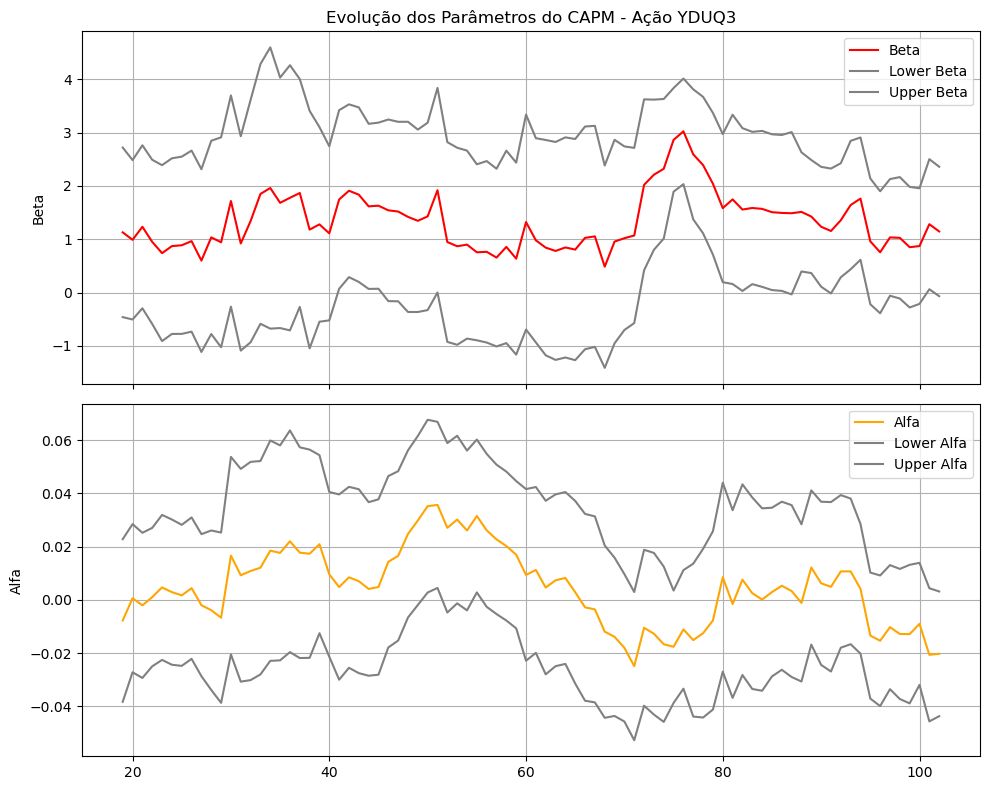

In [28]:
# Criando os gráficos
for acao in tqdm(resultados_rolling['Ação'].unique()):
    plt.close()
    df_acao = resultados_rolling[resultados_rolling['Ação'] == acao]

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

    # Gráfico do Beta
    axes[0].plot(df_acao['Data_Fim'], df_acao['Beta'], label='Beta', color='red')
    axes[0].plot(df_acao['Data_Fim'], df_acao['Lower_Beta'], label='Lower Beta', color='grey')
    axes[0].plot(df_acao['Data_Fim'], df_acao['Upper_Beta'], label='Upper Beta', color='grey')
    axes[0].set_ylabel('Beta')
    axes[0].set_title(f'Evolução dos Parâmetros do CAPM - Ação {acao}')
    axes[0].legend()
    axes[0].grid(True)

    # Gráfico do Alfa
    axes[1].plot(df_acao['Data_Fim'], df_acao['Alfa'], label='Alfa', color='orange')
    axes[1].plot(df_acao['Data_Fim'], df_acao['Lower_Alfa'], label='Lower Alfa', color='grey')
    axes[1].plot(df_acao['Data_Fim'], df_acao['Upper_Alfa'], label='Upper Alfa', color='grey')
    axes[1].set_ylabel('Alfa')
    axes[1].legend()
    axes[1].grid(True)
    
    fig.get_figure().savefig( Path(figure_dir, 'fama_weekly_rolling_' + acao + '.png'), dpi = 400)
    plt.tight_layout()

plt.show()

# 4 EXPORTAÇÃO

In [ ]:
resultados.to_excel(Path(output_dir, "fama_weekly_ols.xlsx"))
resultados_rolling.to_excel(Path(output_dir, "fama_weekly_rolling.xlsx"))